<a href="https://colab.research.google.com/github/prlputriih/machine_learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:
import pandas as pd
import pandas as dataframe
import string
import nltk
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import collections
import sys
import os
import numpy
import seaborn as sns
import csv
from collections import OrderedDict
from nltk.tokenize import word_tokenize
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from pylab import figure, axes, pie, title, show
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [176]:
github_csv_url = 'https://raw.githubusercontent.com/prlputriih/machine_learning/refs/heads/main/mybca_reviews.csv' # Example: make sure this is a RAW GitHub CSV link, not a GitHub page link

try:
    # Ensure pandas is imported (e.g., in an earlier cell: import pandas as pd)
    df_github = pd.read_csv(github_csv_url, sep=';')
    print("CSV loaded successfully from GitHub!")
    display(df_github.head())
except NameError as e:
    print(f"Error: {e}. Please ensure 'import pandas as pd' has been executed.")
except Exception as e:
    print(f"Error loading CSV from GitHub: {e}")
    print("Please ensure the URL is a direct raw link to the CSV file (e.g., it starts with raw.githubusercontent.com).")

CSV loaded successfully from GitHub!


,rating,review
0,1,ribet
1,1,"mau daftar bca ,setiap sms koneksi terputus sa..."
2,1,bca buruk sekali orang mau masuk akun BCA send...
3,1,sudah daftar lewat atm terus mau masuk mybca m...
4,1,ribet eror mulu haru download halo BCA buat bi...


In [177]:
# Simpan rating SEBELUM preprocessing
df_github['rating_asli'] = df_github['rating']

# Baru drop dan lanjut preprocessing seperti biasa
df_github = df_github.drop(columns=['rating'])

### Cleaning

In [178]:
print(df_github.isnull().sum())

review         0
rating_asli    0
dtype: int64


In [179]:
print("\nPersentase Missing Values:")
print((df_github.isnull().sum() / len(df_github)) * 100)


Persentase Missing Values:
review         0.0
rating_asli    0.0
dtype: float64


In [180]:
print(f"Number of duplicate reviews before cleaning: {df_github.duplicated(subset=['review']).sum()}")
df_github.drop_duplicates(subset=['review'], inplace=True)
print(f"Number of duplicate reviews after cleaning: {df_github.duplicated(subset=['review']).sum()}")
print(f"DataFrame shape after removing duplicates: {df_github.shape}")

Number of duplicate reviews before cleaning: 17
Number of duplicate reviews after cleaning: 0
DataFrame shape after removing duplicates: (2532, 2)


In [181]:
# Mengubah angka menjadi teks
angka_dict = {
    '0': 'nol',
    '1': 'satu',
    '2': 'dua',
    '3': 'tiga',
    '4': 'empat',
    '5': 'lima',
    '6': 'enam',
    '7': 'tujuh',
    '8': 'delapan',
    '9': 'sembilan'
}

def angka_ke_huruf(text):

    text = str(text)

    hasil = ''

    for char in text:
        if char in angka_dict:
            hasil += ' ' + angka_dict[char] + ' '
        else:
            hasil += char

    return hasil

df_github['angka_text'] = df_github['review'].apply(angka_ke_huruf)

In [182]:
import re

def cleaning_text(text):

    text = str(text)

    # Menghapus URL
    text = re.sub(r'http\S+', '', text)

    # Mengubah strip menjadi spasi (e.g., 'kata-kata' menjadi 'kata kata')
    text = re.sub(r'(\w)-(\w)', r'\1 \2', text)

    # Mengganti semua karakter non-alfabet (kecuali spasi) dengan spasi tunggal.
    # Ini akan menangani titik (tunggal, ganda, atau tiga), koma, dll.,
    # memastikan kata-kata tidak menempel dan ada spasi yang konsisten.
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Menghapus huruf berulang (e.g., 'baikk' menjadi 'baik')
    text = re.sub(r'(.)\1+', r'\1', text)

    # Menghapus spasi berlebih dan spasi di awal/akhir teks
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan cleaning
df_github['cleaning'] = df_github['review'].apply(cleaning_text)

display(df_github[['review', 'cleaning']].head())

,review,cleaning
0,ribet,ribet
1,"mau daftar bca ,setiap sms koneksi terputus sa...",mau daftar bca setiap sms koneksi terputus sam...
2,bca buruk sekali orang mau masuk akun BCA send...,bca buruk sekali orang mau masuk akun BCA send...
3,sudah daftar lewat atm terus mau masuk mybca m...,sudah daftar lewat atm terus mau masuk mybca m...
4,ribet eror mulu haru download halo BCA buat bi...,ribet eror mulu haru download halo BCA buat bi...


### Case Folding

In [183]:
df_github['lowercase'] = df_github['cleaning'].str.lower()

display(df_github[['lowercase']].head())

,lowercase
0,ribet
1,mau daftar bca setiap sms koneksi terputus sam...
2,bca buruk sekali orang mau masuk akun bca send...
3,sudah daftar lewat atm terus mau masuk mybca m...
4,ribet eror mulu haru download halo bca buat bi...


### Normalize

In [184]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [185]:
kamus_normalisasi = {

    # Kata Ganti & Entitas
    'gua': 'saya',
    'gue': 'saya',
    'gw': 'saya',
    'aku': 'saya',
    'aq': 'saya',
    'ak': 'saya',
    'sy': 'saya',
    'user': 'pengguna',

    'bcaku': 'mybca',
    'my bca': 'mybca',
    'bcamobile': 'bca mobile',
    'mbca': 'bca mobile',

    'costumer': 'pelanggan',
    'customer': 'pelanggan',
    'cs': 'customer service',

    # Update & Error
    'update': 'perbarui',
    'up': 'perbarui',
    'updt': 'perbarui',

    'error': 'kesalahan',
    'err': 'kesalahan',
    'eror': 'kesalahan',

    # Sistem & Teknis
    'biometrix': 'biometri',
    'biometrik': 'biometri',

    'maintenance': 'perbaikan',
    'maint': 'perbaikan',
    'maintn': 'perbaikan',

    'servernya': 'server',

    # Telepon & Komunikasi
    'call': 'telepon',
    'telp': 'telepon',
    'telpon': 'telepon',

    'vc': 'video call',

    # Ekspresi
    'adduh': 'aduh',
    'aduuh': 'aduh',
    'aduhh': 'aduh',
    'duh': 'aduh',

    # Login & Akses
    'log in': 'masuk',
    'login': 'masuk',

    'ahir': 'akhir',
    'aktip': 'aktif',

    # Istilah Aplikasi & Bank
    'apk': 'aplikasi',
    'app': 'aplikasi',
    'aps': 'aplikasi',
    'apknya': 'aplikasi',

    'mbanking': 'mobile banking',
    'ebanking': 'mobile banking',
    'm banking': 'mobile banking',
    'mbangking': 'mobile banking',
    'bangking': 'banking',

    'tf': 'transfer',
    'trf': 'transfer',
    'tanfer': 'transfer',
    'terasfer': 'transfer',

    'pw': 'password',
    'pass': 'password',
    'pasword': 'password',

    'rek': 'rekening',

    'finasial': 'finansial',

    'poto': 'foto',

    'develover': 'developer',
    'programing': 'programming',

    'op': 'otp',

    'walt': 'wallet',

    'flaz': 'flazz',
    'flaazz': 'flazz',
    'flass': 'flazz',
    'flas': 'flazz',

    # Negasi
    'ga': 'tidak',
    'gx': 'tidak',
    'gak': 'tidak',
    'ngga': 'tidak',
    'engga': 'tidak',
    'gk': 'tidak',
    'g': 'tidak',
    'tdk': 'tidak',
    'tida': 'tidak',
    'nda': 'tidak',
    'ndak': 'tidak',

    'gada': 'tidak ada',
    'gamasuk': 'tidak masuk',

    'blm': 'belum',

    # Intensifier
    'bet': 'sangat',
    'bgt': 'sangat',
    'banget': 'sangat',
    'bener': 'sangat',
    'parah': 'sangat',

    # Typo & Slang
    'ya': 'iya',

    'lgi': 'lagi',
    'lg': 'lagi',
    'n': 'dan',
    'd': 'di',

    'haru': 'harus',
    'hrs': 'harus',
    'hrus': 'harus',

    'palayanan': 'pelayanan',

    'timbang': 'banding',

    'urgent': 'desak',

    'negri': 'negeri',

    'nmr': 'nomor',
    'nomer': 'nomor',

    'riber': 'rumit',
    'ribet': 'rumit',
    'ribett': 'rumit',
    'repot': 'rumit',

    'benerin': 'perbaiki',
    'nyalahin': 'menyalahkan',
    'bermasalh': 'bermasalah',

    'plsa': 'pulsa',
    'pilsa': 'pulsa',
    'telkoel': 'telkomsel',
    'telko': 'telkomsel',

    'yg': 'yang',

    'bs': 'bisa',
    'bsa': 'bisa',

    'mnt': 'menit',
    'mnit': 'menit',

    'kocakkk': 'kocak',
    'kocakk': 'kocak',


    'si': 'sih',

    'woi': 'hei',
    'woy': 'hei',

    'ngpain': 'ngapain',

    'udah': 'sudah',
    'udh': 'sudah',
    'uda': 'sudah',
    'dah': 'sudah',

    'sebelumnyauda': 'sebelumnya sudah',

    'jd': 'jadi',
    'jdi': 'jadi',

    'trs': 'terus',
    'trus': 'terus',
    'mulu': 'terus',

    'sm': 'sama',
    'dr': 'dari',
    'utk': 'untuk',

    'kayak': 'seperti',
    'kya': 'seperti',

    'sampai': 'hingga',
    'sampe': 'hingga',
    'smpe': 'hingga',
    'smp': 'hingga',

    'gtu': 'gitu',

    'x': 'kali',

    'trx': 'terus',

    'gjls': 'tidak jelas',
    'gajelas': 'tidak jelas',

    'gmn': 'bagaimana',
    'gimana': 'bagaimana',
    'gimna': 'bagaimana',
    'gimanasih': 'bagaimana sih',

    'sndri': 'sendiri',

    'kl': 'kalau',
    'klo': 'kalau',
    'kalo': 'kalau',

    'aja': 'saja',

    'dlm': 'dalam',

    'bikin': 'membuat',

    'krn': 'karena',

    'dgn': 'dengan',

    'lg': 'lagi',
    'lgi': 'lagi',

    'tp': 'tapi',

    'mau': 'akan',
    'akn': 'akan',

    'prnh': 'pernah',

    'tau': 'tahu',

    'sempet': 'sempat',

    'milih': 'memilih',

    'ngetik': 'mengetik',

    'ngabisin': 'menghabiskan',

    'kelmar kelmer': 'lambat',

    'berjamjam': 'berjam jam',

    'nungguin': 'menunggu',
    'nunggu': 'menunggu',

    'mala': 'malah',

    'balik': 'kembali',

    'bgs': 'bagus',

    'tambahin': 'tambahkan',

    'ko': 'kok',
    'koq': 'kok',

    'emang': 'memang',

    'kesini': 'ke sini',

    'bs': 'bisa',

    'aktifin': 'aktifkan',
    'ngaktifin': 'mengaktifkan',

    'matiin': 'matikan',

    'cm': 'cuma',

    'lgs': 'langsung',

    'y': 'ya',

    'knpa': 'kenapa',
    'tlp': 'telepon',
    'updt': 'update',
    'sy': 'saya',

    'kmaren': 'kemarin',

    'tetep': 'tetap',
    'ttp': 'tetap',

    'kesedot': 'tersedot',

    'jls': 'jelas',
    'jlsh': 'jelas',

    'tolonk': 'tolong',
    'tlg': 'tolong',


    'lelet': 'lambat',

    'hr': 'hari',

    'pake': 'pakai',

    'prihal': 'perihal',

    'baharu': 'baru',

    'lot': 'slot',
    'lotnya': 'slot',

    # Verifikasi & Sistem
    'verivikaisnya': 'verifikasi',
    'verivikasi': 'verifikasi',
    'verifikasinya': 'verifikasi',
    'vermuk': 'verifikasi wajah',

    # Kata Berimbuhan
    'aplikasinya': 'aplikasi',
    'kedepannya': 'depan',
    'sebelumnya': 'sebelum',
    'setelahnya': 'setelah',
    'sebenarnya': 'benar',
    'sebenernya': 'benar',
    'akhirnya': 'akhir',
    'belakangnya': 'belakang',
    'depannya': 'depan',
    'bukannya': 'tidak',
    'prosesnya': 'proses',
    'fiturnya': 'fitur',
    'updatenya': 'perbarui',
    'OTPnya': 'otp',
    'pulsanya': 'pulsa',
    'biasanya': 'biasa',
    'm-bankingnya': 'mbanking',
    'idnya': 'id',
    'jaringannya': 'jaringan',
    'mukanya': 'wajah',
    'idonesianya': 'indonesia',
    'potongannya': 'potong',
    'makanya': 'maka',
    'akunnya': 'akun',
    'imbasnya': 'imbas',
    'emangnya': 'memang',
    'anehnya': 'aneh',

    'loadingnya': 'memuat',

    'dibalikin': 'kembali',

    'otpnya': 'kode otp',

    'loginnya': 'masuk',

    'baharu':'baru',

    'baharunya': 'baru',

    'mbankingnya': 'mobile banking',

    # Normalize
  'abiss': 'habis',
  'aahh': '',
  'adduuh': 'aduh',
  'abisin': 'habiskan'
}

In [186]:
def normalisasi(text):

    kata_kata = text.split()

    hasil = []

    for kata in kata_kata:

        if kata in kamus_normalisasi:
            hasil.append(kamus_normalisasi[kata])
        else:
            hasil.append(kata)

    return ' '.join(hasil)

df_github['normalisasi'] = df_github['lowercase'].apply(normalisasi)

display(df_github[['lowercase', 'normalisasi']].head())

,lowercase,normalisasi
0,ribet,rumit
1,mau daftar bca setiap sms koneksi terputus sam...,akan daftar bca setiap sms koneksi terputus hi...
2,bca buruk sekali orang mau masuk akun bca send...,bca buruk sekali orang akan masuk akun bca sen...
3,sudah daftar lewat atm terus mau masuk mybca m...,sudah daftar lewat atm terus akan masuk mybca ...
4,ribet eror mulu haru download halo bca buat bi...,rumit kesalahan terus harus download halo bca ...


### Tokenizing

In [187]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [188]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

# Tokenizing
df_github['tokenizing'] = df_github['normalisasi'].apply(word_tokenize)

# Menampilkan hasil
display(df_github[['normalisasi', 'tokenizing']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,normalisasi,tokenizing
0,rumit,[rumit]
1,akan daftar bca setiap sms koneksi terputus hi...,"[akan, daftar, bca, setiap, sms, koneksi, terp..."
2,bca buruk sekali orang akan masuk akun bca sen...,"[bca, buruk, sekali, orang, akan, masuk, akun,..."
3,sudah daftar lewat atm terus akan masuk mybca ...,"[sudah, daftar, lewat, atm, terus, akan, masuk..."
4,rumit kesalahan terus harus download halo bca ...,"[rumit, kesalahan, terus, harus, download, hal..."


### Filtering

In [189]:
import requests

stopwords_github_url = 'https://raw.githubusercontent.com/prlputriih/machine_learning/main/stopwords-id.txt' # Changed to raw link

try:
    response = requests.get(stopwords_github_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    stopwords_custom = response.text.splitlines()
    print("Stopwords loaded successfully from GitHub!")
except requests.exceptions.RequestException as e:
    print(f"Error downloading stopwords from GitHub: {e}")
    stopwords_custom = [] # Fallback to empty list or handle as appropriate

# Melihat isi stopword
print(stopwords_custom[:20])

Stopwords loaded successfully from GitHub!
['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [190]:
def filtering(tokens):

    hasil = []

    for kata in tokens:
        if kata not in stopwords_custom:
            hasil.append(kata)

    return hasil

# Terapkan filtering
df_github['filtering'] = df_github['tokenizing'].apply(filtering)

# Tampilkan hasil
display(df_github[['tokenizing', 'filtering']].head())

,tokenizing,filtering
0,[rumit],[rumit]
1,"[akan, daftar, bca, setiap, sms, koneksi, terp...","[daftar, bca, sms, koneksi, terputus, ludes, p..."
2,"[bca, buruk, sekali, orang, akan, masuk, akun,...","[bca, buruk, orang, masuk, akun, bca, susah, b..."
3,"[sudah, daftar, lewat, atm, terus, akan, masuk...","[daftar, atm, masuk, mybca, diblokir, nomor, a..."
4,"[rumit, kesalahan, terus, harus, download, hal...","[rumit, kesalahan, download, halo, bca, buka, ..."


### Stemming Teks


In [191]:
# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):

    hasil = []

    for kata in tokens:
        stem = stemmer.stem(kata)
        hasil.append(stem)

    return hasil

In [192]:
df_github['stemming'] = df_github['filtering'].apply(stemming)

# Menampilkan hasil
display(df_github[['filtering', 'stemming']].head())

,filtering,stemming
0,[rumit],[rumit]
1,"[daftar, bca, sms, koneksi, terputus, ludes, p...","[daftar, bca, sms, koneksi, putus, ludes, puls..."
2,"[bca, buruk, orang, masuk, akun, bca, susah, b...","[bca, buruk, orang, masuk, akun, bca, susah, b..."
3,"[daftar, atm, masuk, mybca, diblokir, nomor, a...","[daftar, atm, masuk, mybca, blokir, nomor, ane..."
4,"[rumit, kesalahan, download, halo, bca, buka, ...","[rumit, salah, download, halo, bca, buka, iya,..."


In [193]:
df_github['stemming_join'] = df_github['stemming'].apply(lambda x: ' '.join(x))

display(df_github[['stemming', 'stemming_join']].head())

,stemming,stemming_join
0,[rumit],rumit
1,"[daftar, bca, sms, koneksi, putus, ludes, puls...",daftar bca sms koneksi putus ludes pulsa gin
2,"[bca, buruk, orang, masuk, akun, bca, susah, b...",bca buruk orang masuk akun bca susah buka mulu...
3,"[daftar, atm, masuk, mybca, blokir, nomor, ane...",daftar atm masuk mybca blokir nomor aneh coba ...
4,"[rumit, salah, download, halo, bca, buka, iya,...",rumit salah download halo bca buka iya salah p...


In [204]:
from collections import Counter
import pandas as pd

# Set pandas option to display all rows (though display() might still truncate in some environments)
pd.set_option('display.max_rows', None)

# Gabungkan semua kata dari kolom hasil preprocessing
all_words = [word for sublist in df_github['stemming'] for word in sublist]

# Hitung frekuensi kata
word_counts = Counter(all_words)

# Ubah ke DataFrame
df_kata_all = pd.DataFrame(word_counts.items(), columns=['Kata', 'Jumlah'])

# Urutkan dari yang paling sering muncul
df_kata_all = df_kata_all.sort_values(by='Jumlah', ascending=False).reset_index(drop=True)

# Tampilkan seluruh DataFrame menggunakan to_string() untuk memastikan tidak ada truncating
print(df_kata_all.to_string())

                     Kata  Jumlah
0                aplikasi     981
1                    baru     766
2                     bca     725
3                   masuk     681
4                     lot     640
5                    buka     407
6                   gagal     380
7                   saldo     353
8               transaksi     352
9                   pakai     322
10                 tolong     310
11                   kali     295
12                   baik     295
13                  salah     280
14                   kode     239
15             verifikasi     230
16                  susah     229
17                 potong     229
18                  mybca     226
19                    iya     226
20                    pas     178
21                   qris     175
22                  rumit     166
23                     hp     160
24                     my     159
25                    otp     156
26                   bank     152
27                 blokir     148
28            

### TF-IDF (Term Frequency-Inverse Document Frequency)

In [195]:
from collections import Counter
import pandas as pd

# Gabungkan semua kata dari kolom hasil preprocessing
all_words = ' '.join(df_github['stemming_join']).split()

# Hitung frekuensi kata
word_counts = Counter(all_words)

# Ubah ke DataFrame
df_kata = pd.DataFrame(word_counts.items(), columns=['Kata', 'Jumlah'])

# Urutkan dari yang paling sering muncul
df_kata = df_kata.sort_values(by='Jumlah', ascending=False)

# Tampilkan
print(df_kata)

# Kalau mau 20 kata teratas
print(df_kata.head(20))

                     Kata  Jumlah
50               aplikasi     981
38                   baru     766
2                     bca     725
11                  masuk     681
449                   lot     640
14                   buka     407
62                  gagal     380
45                  saldo     353
52              transaksi     352
86                  pakai     322
114                tolong     310
51                   kali     295
206                  baik     295
31                  salah     280
72                   kode     239
126            verifikasi     230
13                  susah     229
47                 potong     229
18                  mybca     226
34                    iya     226
88                    pas     178
369                  qris     175
0                   rumit     166
69                     hp     160
44                     my     159
100                   otp     156
76                   bank     152
19                 blokir     148
73            

In [196]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.8,
    token_pattern=r'(?u)\b\w+\b'
)

In [197]:
# Membuat objek TF-IDF
tfidf = TfidfVectorizer()

# Transformasi TF-IDF
X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

# Melihat ukuran matrix
print(X_tfidf.shape)

(2532, 2989)


In [198]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b"
)

X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

print(X_tfidf.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [199]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# TF-IDF
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b"
)

# Transform text
X_tfidf = tfidf.fit_transform(df_github['stemming_join'])

# Ubah ke DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray())

# Tampilkan
display(tfidf_df.head())

,0,1,2,3,4,5,6,7,8,9,...,2995,2996,2997,2998,2999,3000,3001,3002,3003,3004
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Feature Selection menggunakan Chi-squared


In [200]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np

# Definisikan fitur (X) dari DataFrame TF-IDF
X = tfidf_df

y_dummy = np.random.randint(0, 2, size=len(df_github['stemming_join']))

# Inisialisasi SelectKBest dengan chi2 statistic
selector = SelectKBest(chi2, k=1000)

# Lakukan seleksi fitur
X_new = selector.fit_transform(X, y_dummy)

# Dapatkan indeks fitur yang terpilih
selected_feature_indices = selector.get_support(indices=True)

# Dapatkan nama fitur yang terpilih
selected_feature_names = X.columns[selected_feature_indices]

# Dapatkan skor chi2 dan p-value untuk setiap fitur
chi2_scores = selector.scores_
p_values = selector.pvalues_

# Buat DataFrame untuk menampilkan skor dan p-value
feature_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("Bentuk matriks fitur setelah seleksi:", X_new.shape)


print("\nContoh Fitur yang Terpilih (k=%s):" % selector.k)
print(selected_feature_names[:20])

Bentuk matriks fitur setelah seleksi: (2532, 1000)

Contoh Fitur yang Terpilih (k=1000):
Index([2, 3, 5, 13, 21, 30, 31, 33, 34, 36, 39, 42, 44, 49, 52, 53, 55, 60, 61,
       65],
      dtype='int64')


In [201]:
from sklearn.feature_selection import chi2
import pandas as pd
import numpy as np

# TF-IDF
X = X_tfidf

# Contoh label dummy
# Ganti jika punya label asli
y = np.random.randint(0, 2, size=X.shape[0]) # Corrected: ensure y has the same number of samples as X

# Hitung chi-square
chi_scores, p_values = chi2(X, y)

# Buat DataFrame
chi_df = pd.DataFrame({
    'Kata': tfidf.get_feature_names_out(),
    'Chi_Square': chi_scores,
    'P_Value': p_values
})

# Urutkan dari nilai terbesar
chi_df = chi_df.sort_values(
    by='Chi_Square',
    ascending=False
)

# Tampilkan
display(chi_df.head(20))

,Kata,Chi_Square,P_Value
973,henti,4.026673,0.044786
2652,tangal,3.270144,0.070551
870,gbisa,2.591880,0.107413
2532,skrg,2.428374,0.119156
970,hei,2.381022,0.122817
500,capek,2.365725,0.124026
755,email,2.300583,0.129325
801,finger,2.297606,0.129574
1666,mkin,2.082908,0.148956
962,hbis,2.012901,0.155967


### Word Cloud

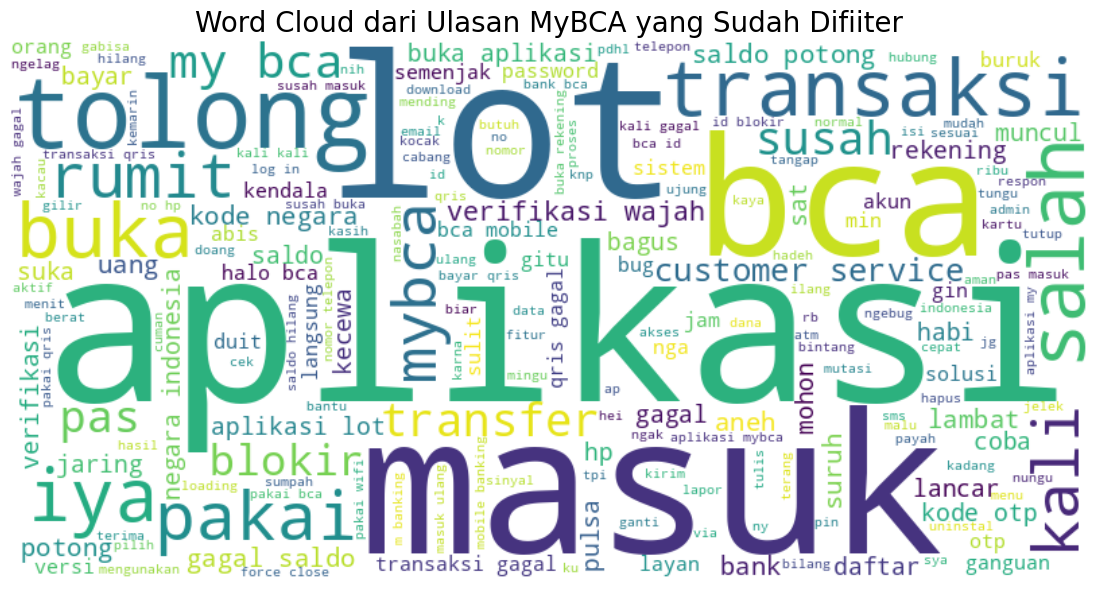

In [202]:
all_filtered_text = ' '.join(df_github['stemming_join'])

# Buat objek WordCloud
wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white',
                      stopwords=stopwords_custom,
                      min_font_size=10).generate(all_filtered_text)

# Tampilkan WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu
plt.title('Word Cloud dari Ulasan MyBCA yang Sudah Difiiter', fontsize=20)
plt.show()

### Sentimen

In [203]:
# Membaca kamus kata positif
with open('sentimen positif.txt', 'r', encoding='utf-8') as file:
    positive_words = file.read().splitlines()

# Melihat isi kamus positif
print(positive_words[:20])

FileNotFoundError: [Errno 2] No such file or directory: 'sentimen positif.txt'

In [ ]:
# Membaca kamus kata negatif
with open('sentimen negatif.txt', 'r', encoding='utf-8') as file:
    negative_words = file.read().splitlines()

# Melihat isi kamus negatif
print(negative_words[:20])

In [ ]:
def sentiment_score(tokens):

    positif = 0
    negatif = 0

    for word in tokens:

        if word in positive_words:
            positif += 1

        elif word in negative_words:
            negatif += 1

    return positif, negatif

In [ ]:
df_github[['positif', 'negatif']] = df_github['stemming'].apply(
    lambda x: pd.Series(sentiment_score(x))
)

display(df_github[['stemming', 'positif', 'negatif']].head())

In [ ]:
def sentiment_label(row):

    if row['positif'] > row['negatif']:
        return 'positif'

    elif row['negatif'] > row['positif']:
        return 'negatif'

    else:
        return 'netral'

In [ ]:
df_github['sentimen'] = df_github.apply(
    sentiment_label,
    axis=1
)

display(df_github[['stemming', 'positif', 'negatif', 'sentimen']].head())

In [ ]:
def cluster_dari_rating(rating):
    if rating in [1, 2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    elif rating in [4, 5]:
        return 'Positive'
    else:
        return 'Unknown'

df_github['cluster'] = df_github['rating_asli'].apply(cluster_dari_rating)

In [ ]:
df_github